# Web Data Science
## Week 10 - Government APIs

INFO 4871/5871. 
[Brian C. Keegan, Ph.D.](http://brianckeegan.com/)  
[Assistant Professor, Department of Information Science](https://www.colorado.edu/cmci/people/information-science/brian-c-keegan)  
University of Colorado Boulder  

Copyright and distributed under an [MIT License](https://opensource.org/licenses/MIT)

In [2]:
# Lets us talk to servers on the web
import requests

# For data manipulation
import pandas as pd
import numpy as np

# We'll need to parse some strings, so we'll write some regular expressions
import re

# Dealing with files and directories
import os, json
from io import StringIO

# Import pyplot
import matplotlib.pyplot as plt

## Census API

The U.S. Census Bureau is responsible for one of the oldest and largest datasets in the country: the [diennial census](https://en.wikipedia.org/wiki/United_States_census) mandated by the U.S. Constitution. In addition to these data, the Census Bureau collects and shares data about a variety of other data including the American Community Survey (estimates every year), population projections, poverty, business and entrepreneurship, health insurance, and geographic information.

### Sign up and login
Go to `https://api.census.gov/data/key_signup.html` and enter "University of Colorado Boulder", your CU email address, and check the Terms of Service agreement box to submit a request for a Census key. You should get an email within about a minute with your key.

Write the key to a simple JSON file that contains only: `{"key":"abcdefghijklmnopqrstuvwxyz1234567890"}` where the long string is the API key that was emailed to you. Read the file into your notebook.

In [3]:
with open('census_api.json','r') as f:
    census_json = json.load(f)

if 'key' in census_json:
    census_key = census_json['key']

In [ ]:
census_key = 'abcdefghijklmnopqrstuvwxyz1234567890'

### Try a query
There is an *enormous* number of datasets available through the Census Data API: https://api.census.gov/data.html ([Wayback backup](https://web.archive.org/web/20230128195530/https://api.census.gov/data.html))

The [American Community Survey](https://www.census.gov/programs-surveys/acs/) ([wiki](https://en.wikipedia.org/wiki/American_Community_Survey)) 5-year estimates are a great place to start for larger municipalities like Boulder. There are several hundred variables to select from. Group and variable names and descriptions of each are available from: https://api.census.gov/data/2021/acs/acs5/variables.json

Start by getting a list of all the "groups", which are collections of variables.

In [4]:
acs_2022_groups = requests.get('https://api.census.gov/data/2022/acs/acs5/groups.json').json()

# Inspect and sample 5
print(pd.DataFrame(acs_2022_groups['groups']).sample(5).loc[:,'description'].values)

['Group Quarters Type (5 Types) by Employment Status'
 'Means of Transportation to Work by Time Arriving at Work for Workplace Geography'
 'Sex by Age by Nativity and Citizenship Status (Native Hawaiian and Other Pacific Islander Alone)'
 'Poverty Status in the Past 12 Months of Related Children Under 18 Years by Family Type by Age of Related Children Under 18 Years'
 'Allocation of Class of Worker for the Full-Time, Year-Round Civilian Employed Population 16 Years and Over']


Repeat for the names of the variables within a group.

In [5]:
acs_2022_variables = requests.get('https://api.census.gov/data/2022/acs/acs5/variables.json').json()

One of my favorite variables is the "YEAR STRUCTURE BUILT" belonging to group "B25034" that breaks down the distribution of ages of residential buildings.

In [6]:
for variable,d in acs_2022_variables['variables'].items():
    if d['group'] == 'B25034':
        print(variable,d['label'])

B25034_010E Estimate!!Total:!!Built 1940 to 1949
B25034_011E Estimate!!Total:!!Built 1939 or earlier
B25034_009E Estimate!!Total:!!Built 1950 to 1959
B25034_008E Estimate!!Total:!!Built 1960 to 1969
B25034_004E Estimate!!Total:!!Built 2000 to 2009
B25034_005E Estimate!!Total:!!Built 1990 to 1999
B25034_006E Estimate!!Total:!!Built 1980 to 1989
B25034_007E Estimate!!Total:!!Built 1970 to 1979
B25034_001E Estimate!!Total:
B25034_002E Estimate!!Total:!!Built 2020 or later
B25034_003E Estimate!!Total:!!Built 2010 to 2019


Make a query.

In [9]:
# Define the API endpoint
census_api_endpoint = 'https://api.census.gov/data'

# Define the API tool to use
census_api_tool = '/2023/acs/acs1'

# Create a parameter dictionary based on API documentation
param_d = {}
param_d['get'] = 'B25034_001E,B25034_002E,B25034_003E,B25034_004E,B25034_005E,B25034_006E,B25034_007E,B25034_008E,B25034_009E,B25034_010E,B25034_011E'
param_d['for'] = 'place:07850'
param_d['in'] = 'state:08'
param_d['key'] = census_key

# Make the request
census_query = requests.get(
    url = census_api_endpoint + census_api_tool,
    params = param_d
)

census_query.text

'[["B25034_001E","B25034_002E","B25034_003E","B25034_004E","B25034_005E","B25034_006E","B25034_007E","B25034_008E","B25034_009E","B25034_010E","B25034_011E","state","place"],\n["47842","1076","4372","4657","4698","8108","10643","6949","3935","413","2991","08","07850"]]'

This is basically a table.

In [10]:
pd.read_json(StringIO(census_query.text))

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,B25034_001E,B25034_002E,B25034_003E,B25034_004E,B25034_005E,B25034_006E,B25034_007E,B25034_008E,B25034_009E,B25034_010E,B25034_011E,state,place
1,47842,1076,4372,4657,4698,8108,10643,6949,3935,413,2991,08,07850


Clean up the DataFrame.

In [12]:
# Turn the API response into a DataFrame
census_df = pd.read_json(StringIO(census_query.text))

# Set the first row to be column names
census_df.columns = census_df.iloc[0]

# Drop the first row with the now redundant column names
census_df.drop(0,inplace=True)

# Mapping dictionary of column names to their more descriptive labels
variable_name_map = {variable:d.get('label').split('!!')[-1] for variable,d in acs_2022_variables['variables'].items() if d['group'] == 'B25034'}

# Use the variable_name_map to rename the columns
census_df.rename(columns=variable_name_map,inplace=True)

# Inspect
census_df

,Total:,Built 2020 or later,Built 2010 to 2019,Built 2000 to 2009,Built 1990 to 1999,Built 1980 to 1989,Built 1970 to 1979,Built 1960 to 1969,Built 1950 to 1959,Built 1940 to 1949,Built 1939 or earlier,state,place
1,47842,1076,4372,4657,4698,8108,10643,6949,3935,413,2991,08,07850


We can pass multiple values to the filters in the API. Let's add Longmont.

In [14]:
# Define the API endpoint
census_api_endpoint = 'https://api.census.gov/data'

# Define the API tool to use
census_api_tool = '/2021/acs/acs5'

# Create a parameter dictionary based on API documentation
param_d = {}
param_d['get'] = 'B25034_001E,B25034_002E,B25034_003E,B25034_004E,B25034_005E,B25034_006E,B25034_007E,B25034_008E,B25034_009E,B25034_010E,B25034_011E'
param_d['for'] = 'place:07850,45970'
param_d['in'] = 'state:08'
param_d['key'] = census_key

# Make the request
census_query = requests.get(
    url = census_api_endpoint + census_api_tool,
    params = param_d
)

census_query.text

'[["B25034_001E","B25034_002E","B25034_003E","B25034_004E","B25034_005E","B25034_006E","B25034_007E","B25034_008E","B25034_009E","B25034_010E","B25034_011E","state","place"],\n["45304","25","3585","3511","5444","7582","8861","8019","4057","752","3468","08","07850"],\n["40908","102","4512","6970","7454","5572","8767","3268","1538","490","2235","08","45970"]]'

Cleanup.

In [16]:
# Turn the API response into a DataFrame
census_df = pd.read_json(StringIO(census_query.text))

# Set the first row to be column names
census_df.columns = census_df.iloc[0]

# Drop the first row with the now redundant column names
census_df.drop(0,inplace=True)

# Mapping dictionary of column names to their more descriptive labels
variable_name_map = {variable:d.get('label').split('!!')[-1] for variable,d in acs_2022_variables['variables'].items() if d['group'] == 'B25034'}

# Use the variable_name_map to rename the columns
census_df.rename(columns=variable_name_map,inplace=True)

# Inspect
census_df

,Total:,Built 2020 or later,Built 2010 to 2019,Built 2000 to 2009,Built 1990 to 1999,Built 1980 to 1989,Built 1970 to 1979,Built 1960 to 1969,Built 1950 to 1959,Built 1940 to 1949,Built 1939 or earlier,state,place
1,45304,25,3585,3511,5444,7582,8861,8019,4057,752,3468,08,07850
2,40908,102,4512,6970,7454,5572,8767,3268,1538,490,2235,08,45970


Make a visual.

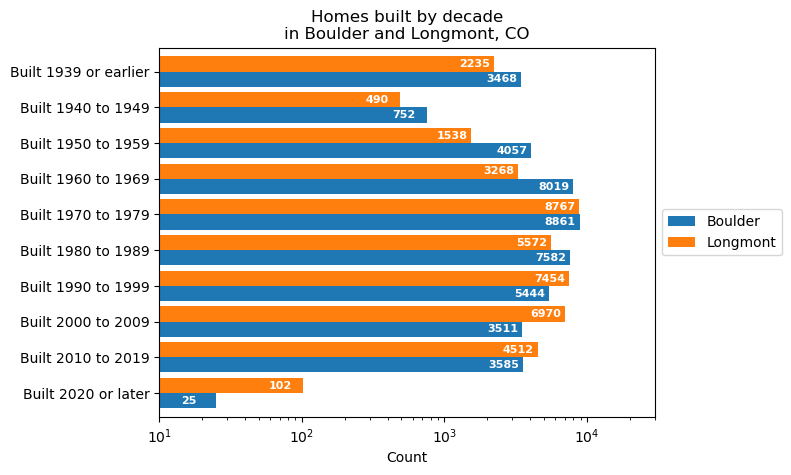

In [17]:
# Cast data to floats
cleaned_census_df = census_df.astype(float).T.drop(['Total:','state','place'])

# Rename columns and index
cleaned_census_df.columns = ['Boulder','Longmont']
cleaned_census_df.index.name = None

# Make a horizontal barplot
f,ax = plt.subplots()
barh = cleaned_census_df.plot.barh(width=.85,ax=ax)
ax.set_xscale('log')
ax.legend(loc='center left',bbox_to_anchor=(1,.5))
ax.set_xlabel('Count')
ax.set_title('Homes built by decade\nin Boulder and Longmont, CO')
ax.set_xlim((1e1,3e4))
ax.bar_label(ax.containers[0],padding=-25,color='w',size=8,fontweight='bold')
ax.bar_label(ax.containers[1],padding=-25,color='w',size=8,fontweight='bold');

### Exercise
Retrieve the "[S2001](https://api.census.gov/data/2022/acs/acs5/subject/groups/S2001.html)" group/variable from the ACS 5-year dataset for all the counties in Colorado. Measure the Male versus Female income disparities for Bachelors degree holders. Make some kind of visualization of these disparities.

In [57]:
# https://api.census.gov/data/2022/acs/acs5/subject/groups/S2001.html

# Define the API endpoint
census_api_endpoint = 'https://api.census.gov/data'

# Define the API tool to use
census_api_tool = '/2017/acs/acs1/subject'

# Create a parameter dictionary based on API documentation
param_d = {}
param_d['get'] = 'S2001_C03_002E,S2001_C05_002E,NAME'
param_d['for'] = 'state:*'
param_d['key'] = census_key

# Make the request
census_query = requests.get(
    url = census_api_endpoint + census_api_tool,
    params = param_d
)

census_query.text

'[["S2001_C03_002E","S2001_C05_002E","NAME","state"],\n["34616","24441","Mississippi","28"],\n["36751","27009","Missouri","29"],\n["33221","24322","Montana","30"],\n["40448","27439","Nebraska","31"],\n["36726","29422","Nevada","32"],\n["46197","31360","New Hampshire","33"],\n["50432","34602","New Jersey","34"],\n["31663","24171","New Mexico","35"],\n["42037","32231","New York","36"],\n["36026","27127","North Carolina","37"],\n["41686","30726","North Dakota","38"],\n["39819","26728","Ohio","39"],\n["35769","25036","Oklahoma","40"],\n["37715","27107","Oregon","41"],\n["41182","29255","Pennsylvania","42"],\n["42084","30413","Rhode Island","44"],\n["34621","25125","South Carolina","45"],\n["37012","26397","South Dakota","46"],\n["35552","26596","Tennessee","47"],\n["38129","27150","Texas","48"],\n["35578","27410","Vermont","50"],\n["40450","22448","Utah","49"],\n["45226","31126","Virginia","51"],\n["46620","31202","Washington","53"],\n["35166","24036","West Virginia","54"],\n["41180","2862

In [58]:
df = pd.read_json(StringIO(census_query.text))

df.columns = df.iloc[0]

df = df.drop(index = 0)

df.columns = ['Male median','Female median','State','State ID']

df[['Male median','Female median']] = df[['Male median','Female median']].astype(int)

df['Disparity'] = df['Male median'] - df['Female median']

df.sort_values('Disparity')

,Male median,Female median,State,State ID,Disparity
28,16832,17113,Puerto Rico,72,-281
38,33572,26412,Florida,12,7160
5,36726,29422,Nevada,32,7304
8,31663,24171,New Mexico,35,7492
31,35887,28139,Arizona,04,7748
21,35578,27410,Vermont,50,8168
36,60167,51904,District of Columbia,11,8263
48,36359,27724,Maine,23,8635
35,40854,31966,Delaware,10,8888
10,36026,27127,North Carolina,37,8899


## FRED API

The Federal Reserve Bank of St. Louis maintains a large database of economic (finance, banking, business, macro-indicators, demography, trade, etc.) data called the Federal Reserve Economic Data, or "FRED". FRED has a REST API for interfacing with this database but you must register an account with your email and request an API key for an application. Here is the [documentation](https://fred.stlouisfed.org/docs/api/fred/) for the API as well.

### Sign up and login
Go to `https://fredaccount.stlouisfed.org/`, click the "Register" button under "Want to create a new account?", enter your email or "Sign in with Google". 

![](fred_signup.png)

Click the "Request API Key" button and fill out the simple form with a basic description (e.g., "Exploratory data analyses for a web data scraping class"), and consent to the agreements. The API key should appear immediately.

![](fred_description.png)

Write the key to a JSON file and then read the file into your notebook.

In [59]:
with open('fred_api.json','r') as f:
    fred_json = json.load(f)

if 'key' in fred_json:
    fred_key = fred_json['key']

In [ ]:
fred_key = 'abcdefghijklmnopqrstuvwxyz1234567890'

### Try a query against the FRED API

You can try to navigate to different FRED datasets (called "series") through the API, but in practice, I find the names of the series through the web interface and then retrieve the data once I have the name. Retrieve the data for the "[All-Transactions House Price Index for Boulder County, CO](https://fred.stlouisfed.org/series/ATNHPIUS08013A)" which has a series name of "ATNHPIUS08013A".

![](fred_ATNHPIUS08013A.png)

We can get some meta-data about the series from the `/series` tool.

In [60]:
# Define the API endpoint
fred_api_endpoint = 'https://api.stlouisfed.org/fred'

# Define the API tool to use
fred_api_tool = '/series'

# Create a parameter dictionary based on API documentation
param_d = {}
param_d['series_id'] = 'ATNHPIUS08013A'
param_d['api_key'] = fred_key
param_d['file_type'] = 'json'

# Make the request
fred_query = requests.get(
    url = fred_api_endpoint + fred_api_tool,
    params = param_d
)

fred_query.json()

{'realtime_start': '2024-11-05',
 'realtime_end': '2024-11-05',
 'seriess': [{'id': 'ATNHPIUS08013A',
   'realtime_start': '2024-11-05',
   'realtime_end': '2024-11-05',
   'title': 'All-Transactions House Price Index for Boulder County, CO',
   'observation_start': '1975-01-01',
   'observation_end': '2023-01-01',
   'frequency': 'Annual',
   'frequency_short': 'A',
   'units': 'Index 2000=100',
   'units_short': 'Index 2000=100',
   'seasonal_adjustment': 'Not Seasonally Adjusted',
   'seasonal_adjustment_short': 'NSA',
   'last_updated': '2024-03-26 09:02:07-05',
   'popularity': 8,
   'notes': 'As stated by the source, these annual county indexes should be considered developmental. As with the standard FHFA HPIs, revisions to these indexes may reflect the impact of new data or technical adjustments. Indexes are calibrated using appraisal values and sales prices for mortgages bought or guaranteed by Fannie Mae and Freddie Mac. As discussed in the Working Paper 16-01, in cases where 

To get the actual data, we need the `/observations` tool.

In [61]:
# Define the API tool to use
fred_api_tool = '/series/observations'

# Create a parameter dictionary based on API documentation
param_d = {}
param_d['series_id'] = 'ATNHPIUS08013A'
param_d['api_key'] = fred_key
param_d['file_type'] = 'json'

# Make the request
fred_query = requests.get(
    url = fred_api_endpoint + fred_api_tool,
    params = param_d
)

fred_query.json()

{'realtime_start': '2024-11-05',
 'realtime_end': '2024-11-05',
 'observation_start': '1600-01-01',
 'observation_end': '9999-12-31',
 'units': 'lin',
 'output_type': 1,
 'file_type': 'json',
 'order_by': 'observation_date',
 'sort_order': 'asc',
 'count': 49,
 'offset': 0,
 'limit': 100000,
 'observations': [{'realtime_start': '2024-11-05',
   'realtime_end': '2024-11-05',
   'date': '1975-01-01',
   'value': '16.28'},
  {'realtime_start': '2024-11-05',
   'realtime_end': '2024-11-05',
   'date': '1976-01-01',
   'value': '18.04'},
  {'realtime_start': '2024-11-05',
   'realtime_end': '2024-11-05',
   'date': '1977-01-01',
   'value': '21.45'},
  {'realtime_start': '2024-11-05',
   'realtime_end': '2024-11-05',
   'date': '1978-01-01',
   'value': '25.33'},
  {'realtime_start': '2024-11-05',
   'realtime_end': '2024-11-05',
   'date': '1979-01-01',
   'value': '29.50'},
  {'realtime_start': '2024-11-05',
   'realtime_end': '2024-11-05',
   'date': '1980-01-01',
   'value': '31.84'},
 

Turn the "observations" into a DataFrame.

In [62]:
fred_housing_price_df = pd.DataFrame(fred_query.json()['observations'])

# Clean up extraneous columns
fred_housing_price_df = fred_housing_price_df[['date','value']]

# Rename columns
fred_housing_price_df.columns = ['date','housing']

# Cast housing values from str to float
fred_housing_price_df['housing'] = fred_housing_price_df['housing'].astype(np.float32)

# Cast dates from strings to Timestamps
fred_housing_price_df['date'] = pd.to_datetime(fred_housing_price_df['date'])

# Make the "date" column the index
fred_housing_price_df.set_index('date',inplace=True)

# Inspect
fred_housing_price_df.head()

,housing
date,
1975-01-01,16.280001
1976-01-01,18.040001
1977-01-01,21.450001
1978-01-01,25.330000
1979-01-01,29.500000


<Axes: xlabel='date'>

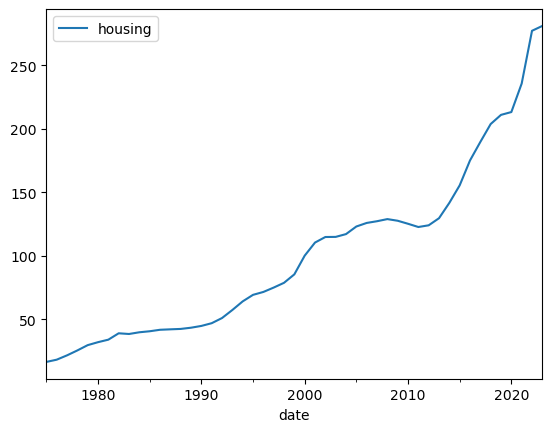

In [63]:
fred_housing_price_df.plot()

Extract the observations for the series "[Estimate of Median Household Income for Boulder County, CO](https://fred.stlouisfed.org/series/MHICO08013A052NCEN)", which has a series name "MHICO08013A052NCEN". Reading the [documentation](https://fred.stlouisfed.org/docs/api/fred/series_observations.html) for the `/series/observations` tool, we can pass a parameter "output_type" that will skip the "realtime_start" and "realtime_end" values that appeared in the results before. Also note that the values returned are strings that contain missing data and will need to be converted to numeric values.

In [64]:
# Define the API tool to use
fred_api_tool = '/series/observations'

# Create a parameter dictionary based on API documentation
param_d = {}
param_d['series_id'] = 'MHICO08013A052NCEN'
param_d['output_type'] = 2
param_d['api_key'] = fred_key
param_d['file_type'] = 'json'

# Make the request
fred_query = requests.get(
    url = fred_api_endpoint + fred_api_tool,
    params = param_d
)

fred_query.json()

{'realtime_start': '2024-11-05',
 'realtime_end': '2024-11-05',
 'observation_start': '1600-01-01',
 'observation_end': '9999-12-31',
 'units': 'lin',
 'output_type': 2,
 'file_type': 'json',
 'order_by': 'observation_date',
 'sort_order': 'asc',
 'count': 34,
 'offset': 0,
 'limit': 100000,
 'observations': [{'date': '1989-01-01',
   'MHICO08013A052NCEN_20241105': '34200'},
  {'date': '1990-01-01', 'MHICO08013A052NCEN_20241105': '.'},
  {'date': '1991-01-01', 'MHICO08013A052NCEN_20241105': '.'},
  {'date': '1992-01-01', 'MHICO08013A052NCEN_20241105': '.'},
  {'date': '1993-01-01', 'MHICO08013A052NCEN_20241105': '41676'},
  {'date': '1994-01-01', 'MHICO08013A052NCEN_20241105': '.'},
  {'date': '1995-01-01', 'MHICO08013A052NCEN_20241105': '46199'},
  {'date': '1996-01-01', 'MHICO08013A052NCEN_20241105': '.'},
  {'date': '1997-01-01', 'MHICO08013A052NCEN_20241105': '50245'},
  {'date': '1998-01-01', 'MHICO08013A052NCEN_20241105': '54503'},
  {'date': '1999-01-01', 'MHICO08013A052NCEN_202

Turn this into a DataFrame.

In [65]:
# Read observations into a DataFrame
fred_household_income_df = pd.DataFrame(fred_query.json()['observations'])

# Rename columns
fred_household_income_df.columns = ['date','income']

# Cast dates from strings to Timestamps
fred_household_income_df['date'] = pd.to_datetime(fred_household_income_df['date'])

# Set the "date" column as an index
fred_household_income_df.set_index('date',inplace=True)

# Replace the "." with NaN
fred_household_income_df.replace({'income':{'.':np.NaN}},inplace=True)

# Cast the "income" column from str to float
fred_household_income_df['income'] = fred_household_income_df['income'].astype(np.float32)

# Interpolate the missing data
fred_household_income_df['income'] = fred_household_income_df['income'].interpolate()

# Inspect
fred_household_income_df.head()

,income
date,
1989-01-01,34200.0
1990-01-01,36069.0
1991-01-01,37938.0
1992-01-01,39807.0
1993-01-01,41676.0


Merge both datasets together.

In [66]:
fred_merged_df = pd.concat([fred_housing_price_df,fred_household_income_df],axis=1)

# Normalize "income" column values to be 100 for the year 2000
fred_merged_df.loc[:,'income'] = fred_merged_df.loc[:,'income'] / fred_merged_df.loc['2000-01-01','income'] * 100

# Inspect
fred_merged_df.tail()

,housing,income
date,,
2019-01-01,210.949997,150.749985
2020-01-01,213.169998,150.661255
2021-01-01,235.619995,154.139008
2022-01-01,277.200012,164.816299
2023-01-01,281.040009,NaN


Here's a plot to make you angry!

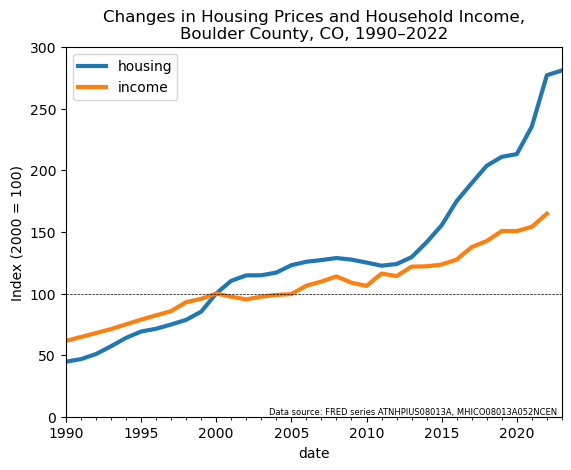

In [67]:
# Setup plot environment
f,ax = plt.subplots()

# Plot the data from 1990 forwards into ax with linewidth of 3
fred_merged_df.loc['1990':].plot(lw=3,ax=ax)

# Label axes and titles
ax.set_ylabel('Index (2000 = 100)')
ax.axhline(100,ls='--',lw=.5,c='k')
ax.set_title('Changes in Housing Prices and Household Income,\nBoulder County, CO, 1990–2022')

ax.set_ylim((0,300))

# Add annotation with source
ax.annotate(
    'Data source: FRED series ATNHPIUS08013A, MHICO08013A052NCEN',
    xy=(.99,0),
    xycoords='axes fraction',
    fontsize=6,
    ha='right',
    va='bottom'
)

f.savefig('boulder_housing_income.png')

### Exercise
Get the observations for the series "[New Private Housing Structures Authorized by Building Permits for Boulder County, CO](https://fred.stlouisfed.org/series/BPPRIV008013)" (BPPRIV008013). 

Clean up the data, normalize values to 100 for the year 2000, add to the `fred_merged_df`, and plot alongside the housing prices and household incomes.

In [72]:
# Define the API tool to use
fred_api_tool = '/series/observations'

# Create a parameter dictionary based on API documentation
param_d = {}
param_d['series_id'] = 'BPPRIV008013'
param_d['output_type'] = 2
param_d['api_key'] = fred_key
param_d['file_type'] = 'json'

# Make the request
fred_query = requests.get(
    url = fred_api_endpoint + fred_api_tool,
    params = param_d
)

fred_query.json()

{'realtime_start': '2024-11-05',
 'realtime_end': '2024-11-05',
 'observation_start': '1600-01-01',
 'observation_end': '9999-12-31',
 'units': 'lin',
 'output_type': 2,
 'file_type': 'json',
 'order_by': 'observation_date',
 'sort_order': 'asc',
 'count': 34,
 'offset': 0,
 'limit': 100000,
 'observations': [{'date': '1990-01-01', 'BPPRIV008013_20241105': '1460'},
  {'date': '1991-01-01', 'BPPRIV008013_20241105': '1550'},
  {'date': '1992-01-01', 'BPPRIV008013_20241105': '2799'},
  {'date': '1993-01-01', 'BPPRIV008013_20241105': '3067'},
  {'date': '1994-01-01', 'BPPRIV008013_20241105': '2623'},
  {'date': '1995-01-01', 'BPPRIV008013_20241105': '3094'},
  {'date': '1996-01-01', 'BPPRIV008013_20241105': '2744'},
  {'date': '1997-01-01', 'BPPRIV008013_20241105': '3259'},
  {'date': '1998-01-01', 'BPPRIV008013_20241105': '5136'},
  {'date': '1999-01-01', 'BPPRIV008013_20241105': '2992'},
  {'date': '2000-01-01', 'BPPRIV008013_20241105': '2780'},
  {'date': '2001-01-01', 'BPPRIV008013_202

In [73]:
# Clean it up

# Read observations into a DataFrame
fred_housing_permits_df = pd.DataFrame(fred_query.json()['observations'])

# Rename columns
fred_housing_permits_df.columns = ['date','permits']

# Cast dates from strings to Timestamps
fred_housing_permits_df['date'] = pd.to_datetime(fred_housing_permits_df['date'])

# Set the "date" column as an index
fred_housing_permits_df.set_index('date',inplace=True)

# Cast the "income" column from str to float
fred_housing_permits_df['permits'] = fred_housing_permits_df['permits'].astype(float)

# Inspect
fred_housing_permits_df.head()

,permits
date,
1990-01-01,1460.0
1991-01-01,1550.0
1992-01-01,2799.0
1993-01-01,3067.0
1994-01-01,2623.0


<Axes: xlabel='date'>

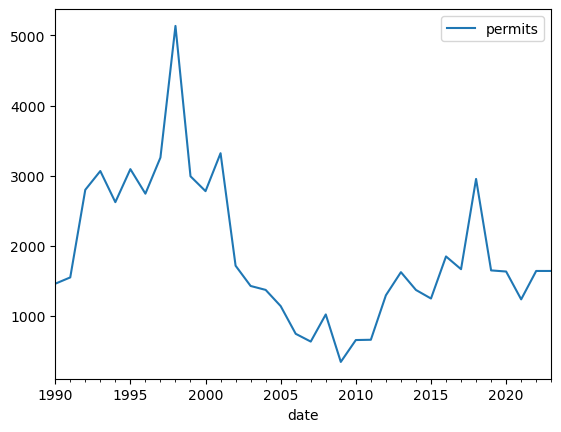

In [74]:
fred_housing_permits_df.plot()

Add in mortgage rates.

In [75]:
# MORTGAGE30US


# Define the API tool to use
fred_api_tool = '/series/observations'

# Create a parameter dictionary based on API documentation
param_d = {}
param_d['series_id'] = 'MORTGAGE30US'
param_d['frequency'] = 'a'
param_d['aggregation_method'] = 'avg'
param_d['api_key'] = fred_key
param_d['file_type'] = 'json'

# Make the request
fred_query = requests.get(
    url = fred_api_endpoint + fred_api_tool,
    params = param_d
)

# Clean it up

# Read observations into a DataFrame
fred_mortgage_rates_df = pd.DataFrame(fred_query.json()['observations'])

fred_mortgage_rates_df = fred_mortgage_rates_df[['date','value']]

# Rename columns
fred_mortgage_rates_df.columns = ['date','rates']

# Cast dates from strings to Timestamps
fred_mortgage_rates_df['date'] = pd.to_datetime(fred_mortgage_rates_df['date'])

# Set the "date" column as an index
fred_mortgage_rates_df.set_index('date',inplace=True)

# Cast the "income" column from str to float
fred_mortgage_rates_df['rates'] = fred_mortgage_rates_df['rates'].astype(float)

fred_mortgage_rates_df.head()

,rates
date,
1971-01-01,7.54
1972-01-01,7.38
1973-01-01,8.04
1974-01-01,9.19
1975-01-01,9.05


In [76]:
# Merge with fred_merged_df

fred_merged_df = pd.concat([fred_housing_price_df,fred_household_income_df,fred_housing_permits_df,fred_mortgage_rates_df],axis=1)

# Normalize "income" column values to be 100 for the year 2000
fred_merged_df.loc[:,'income'] = fred_merged_df.loc[:,'income'] / fred_merged_df.loc['2000-01-01','income'] * 100
fred_merged_df.loc[:,'permits'] = fred_merged_df.loc[:,'permits'] / fred_merged_df.loc['2000-01-01','permits'] * 100
fred_merged_df.loc[:,'rates'] = fred_merged_df.loc[:,'rates'] / fred_merged_df.loc['2000-01-01','rates'] * 100

# Inspect
fred_merged_df.tail()

,housing,income,permits,rates
date,,,,
2020-01-01,213.169998,150.661255,58.776978,38.633540
2021-01-01,235.619995,154.139008,44.496403,36.770186
2022-01-01,277.200012,164.816299,59.064748,66.335404
2023-01-01,281.040009,NaN,59.064748,84.596273
2024-01-01,NaN,NaN,NaN,83.354037


<Axes: xlabel='date'>

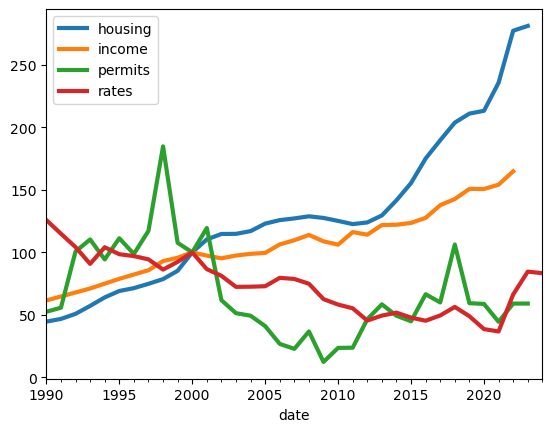

In [77]:
# Plot it
fred_merged_df.loc['1990':,:].plot(lw=3)

### Advanced API functionality

The API can return the raw values, from which you could compute your own statistics (change, percentage change, log transformation, *etc*.) or aggregate to another frequency. The API can also compute these statistics and transformations for you.

Take the "[Consumer Opinion Surveys: Confidence Indicators: Composite Indicators: OECD Indicator for United States](https://fred.stlouisfed.org/series/CSCICP03USM665S)" (CSCICP03USM665S), which is measured monthly since January 1960.

In [78]:
# Define the API tool to use
fred_api_tool = '/series/observations'

# Create a parameter dictionary based on API documentation
param_d = {}
param_d['series_id'] = 'CSCICP03USM665S'
param_d['output_type'] = 2
param_d['api_key'] = fred_key
param_d['file_type'] = 'json'

# Make the request
fred_query = requests.get(
    url = fred_api_endpoint + fred_api_tool,
    params = param_d
)

# Inspect the first ten observations
fred_query.json()['observations'][:10]

[{'date': '1960-01-01', 'CSCICP03USM665S_20241105': '101.6328'},
 {'date': '1960-02-01', 'CSCICP03USM665S_20241105': '101.3749'},
 {'date': '1960-03-01', 'CSCICP03USM665S_20241105': '101.1521'},
 {'date': '1960-04-01', 'CSCICP03USM665S_20241105': '101.0292'},
 {'date': '1960-05-01', 'CSCICP03USM665S_20241105': '101.0603'},
 {'date': '1960-06-01', 'CSCICP03USM665S_20241105': '101.1481'},
 {'date': '1960-07-01', 'CSCICP03USM665S_20241105': '101.1666'},
 {'date': '1960-08-01', 'CSCICP03USM665S_20241105': '101.0264'},
 {'date': '1960-09-01', 'CSCICP03USM665S_20241105': '100.8089'},
 {'date': '1960-10-01', 'CSCICP03USM665S_20241105': '100.6283'}]

Plot it cause I'm curious.

(96.0, 103.0)

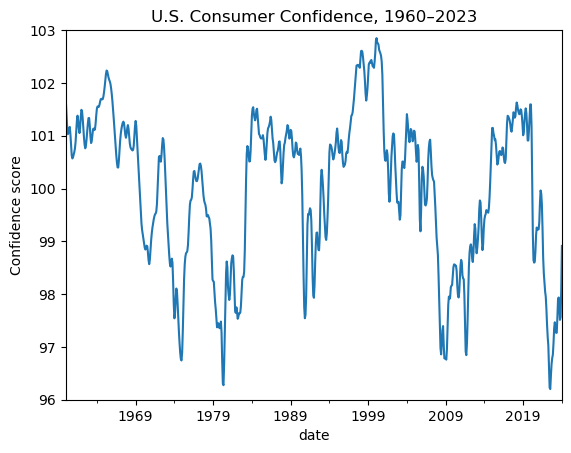

In [79]:
# Turn into a DataFrame
confidence_df = pd.DataFrame(fred_query.json()['observations'])

# Rename columns
confidence_df.columns = ['date','confidence']

# Cast date to Timestamps
confidence_df['date'] = pd.to_datetime(confidence_df['date'])

# Cast confidence to floats
confidence_df['confidence'] = confidence_df['confidence'].astype(float)

# Set date as index
confidence_df.set_index('date',inplace=True)

# Plot
ax = confidence_df['confidence'].plot()
ax.set_title('U.S. Consumer Confidence, 1960–2023')
ax.set_ylabel('Confidence score')
ax.set_ylim((96,103))

Following the `/series/observations` [documentation](https://fred.stlouisfed.org/docs/api/fred/series_observations.html), we can pass some additional parameters to get the same data back with different frequencies or statistics.

Convert the monthly data to the quarterly average. For some reason, the "output_type" has to be set back to its default value of 1.

In [82]:
# Define the API tool to use
fred_api_tool = '/series/observations'

# Create a parameter dictionary based on API documentation
param_d = {}
param_d['series_id'] = 'CSCICP03USM665S'
param_d['frequency'] = 'a'
param_d['aggregation_method'] = 'avg'
param_d['api_key'] = fred_key
# param_d['output_type'] = 2
param_d['file_type'] = 'json'

# Make the request
fred_query = requests.get(
    url = fred_api_endpoint + fred_api_tool,
    params = param_d
)

# Inspect the first ten observations
fred_query.json()['observations'][:10]

[{'realtime_start': '2024-11-05',
  'realtime_end': '2024-11-05',
  'date': '1960-01-01',
  'value': '101.01567500000000'},
 {'realtime_start': '2024-11-05',
  'realtime_end': '2024-11-05',
  'date': '1961-01-01',
  'value': '101.05817500000000'},
 {'realtime_start': '2024-11-05',
  'realtime_end': '2024-11-05',
  'date': '1962-01-01',
  'value': '101.11446666666667'},
 {'realtime_start': '2024-11-05',
  'realtime_end': '2024-11-05',
  'date': '1963-01-01',
  'value': '101.11654166666667'},
 {'realtime_start': '2024-11-05',
  'realtime_end': '2024-11-05',
  'date': '1964-01-01',
  'value': '101.64416666666667'},
 {'realtime_start': '2024-11-05',
  'realtime_end': '2024-11-05',
  'date': '1965-01-01',
  'value': '102.05160000000000'},
 {'realtime_start': '2024-11-05',
  'realtime_end': '2024-11-05',
  'date': '1966-01-01',
  'value': '100.88308333333333'},
 {'realtime_start': '2024-11-05',
  'realtime_end': '2024-11-05',
  'date': '1967-01-01',
  'value': '101.10822500000000'},
 {'realt

Convert the monthly data to the percent change from 1 year ago.

In [85]:
# Define the API tool to use
fred_api_tool = '/series/observations'

# Create a parameter dictionary based on API documentation
param_d = {}
param_d['series_id'] = 'CSCICP03USM665S'
param_d['units'] = 'pc1'
param_d['api_key'] = fred_key
param_d['file_type'] = 'json'
param_d['output_type'] = 2

# Make the request
fred_query = requests.get(
    url = fred_api_endpoint + fred_api_tool,
    params = param_d
)

# Inspect the first ten observations
fred_query.json()['observations'][10:20]

[{'date': '1960-11-01', 'CSCICP03USM665S_PC1_20241107': '.'},
 {'date': '1960-12-01', 'CSCICP03USM665S_PC1_20241107': '.'},
 {'date': '1961-01-01', 'CSCICP03USM665S_PC1_20241107': '-0.97744'},
 {'date': '1961-02-01', 'CSCICP03USM665S_PC1_20241107': '-0.67443'},
 {'date': '1961-03-01', 'CSCICP03USM665S_PC1_20241107': '-0.38754'},
 {'date': '1961-04-01', 'CSCICP03USM665S_PC1_20241107': '-0.14570'},
 {'date': '1961-05-01', 'CSCICP03USM665S_PC1_20241107': '0.02038'},
 {'date': '1961-06-01', 'CSCICP03USM665S_PC1_20241107': '0.13317'},
 {'date': '1961-07-01', 'CSCICP03USM665S_PC1_20241107': '0.21074'},
 {'date': '1961-08-01', 'CSCICP03USM665S_PC1_20241107': '0.26221'}]

### Comparing CPI data for two locations

In [118]:
# Food
# Define the API tool to use
fred_api_tool = '/series/observations'

# Create a parameter dictionary based on API documentation
param_d = {}
param_d['series_id'] = 'CPIUFDSL'
# param_d['units'] = 'pc1'
param_d['api_key'] = fred_key
param_d['file_type'] = 'json'
# param_d['output_type'] = 2

# Make the request
fred_query = requests.get(
    url = fred_api_endpoint + fred_api_tool,
    params = param_d
)

fred_query.json()['observations']

[{'realtime_start': '2024-11-06',
  'realtime_end': '2024-11-06',
  'date': '1947-01-01',
  'value': '22.8'},
 {'realtime_start': '2024-11-06',
  'realtime_end': '2024-11-06',
  'date': '1947-02-01',
  'value': '23.1'},
 {'realtime_start': '2024-11-06',
  'realtime_end': '2024-11-06',
  'date': '1947-03-01',
  'value': '23.8'},
 {'realtime_start': '2024-11-06',
  'realtime_end': '2024-11-06',
  'date': '1947-04-01',
  'value': '23.5'},
 {'realtime_start': '2024-11-06',
  'realtime_end': '2024-11-06',
  'date': '1947-05-01',
  'value': '23.4'},
 {'realtime_start': '2024-11-06',
  'realtime_end': '2024-11-06',
  'date': '1947-06-01',
  'value': '23.5'},
 {'realtime_start': '2024-11-06',
  'realtime_end': '2024-11-06',
  'date': '1947-07-01',
  'value': '23.8'},
 {'realtime_start': '2024-11-06',
  'realtime_end': '2024-11-06',
  'date': '1947-08-01',
  'value': '24.1'},
 {'realtime_start': '2024-11-06',
  'realtime_end': '2024-11-06',
  'date': '1947-09-01',
  'value': '24.8'},
 {'realtim

In [116]:
# Get data for Denver-Aurora-Lakewood: CUUSA433SA0

# Define the API tool to use
fred_api_tool = '/series/observations'

# Create a parameter dictionary based on API documentation
param_d = {}
param_d['series_id'] = 'CPIEHOUSE'
# param_d['units'] = 'pc1'
param_d['api_key'] = fred_key
param_d['file_type'] = 'json'
param_d['frequency'] = 'a'
param_d['aggregation_method'] = 'avg'
# param_d['output_type'] = 2

# Make the request
fred_query = requests.get(
    url = fred_api_endpoint + fred_api_tool,
    params = param_d
)

# atlanta_cpi = pd.Series([pd.to_numeric(list(d.values())[1],errors='coerce') for d in fred_query.json()['observations']])
atlanta_cpi.plot()

KeyError: 'observations'

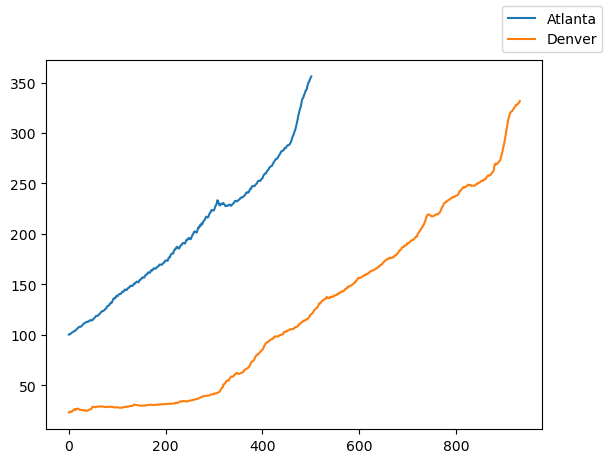

In [114]:
f,ax = plt.subplots()

atlanta_cpi.plot(ax=ax,label='Atlanta')
denver_cpi.plot(ax=ax,label='Denver')

f.legend()

## FEC API

The [Federal Elections Commission](https://www.fec.gov/) (FEC) is the U.S. federal agency charged with regulating elections, candidates, and campaign fundraising. The FEC has a [REST API](https://api.open.fec.gov/developers/) for interfacing with the agency's [bulk downloads](https://www.fec.gov/data/browse-data/?tab=bulk-data). The API has a rate limit of 1000 calls/hour.

### Signup and login
Make a request for an API key by filling out [this form](https://api.open.fec.gov/developers/).
![](fec_api_signup.png)

The key should be generated immediately and arrive in your inbox within a few seconds.
![](fec_api_key.png)

Practice storing your key in a text file and loading it into a notebook afterwards.

In [119]:
data_gov_json = 'abcd1234'

with open('datagov_api.json','r') as f:
    data_gov_json = json.load(f)

if 'key' in data_gov_json:
    data_gov_key = data_gov_json['key']

### Try a query agaisnt the FEC API

What is Joe Biden's FEC candidate ID? Use the `/candidates/search/` API tool to search for candidates matching the term "biden" and running for President in 2024.

In [128]:
# Define the API endpoint
fec_api_endpoint = 'https://api.open.fec.gov/v1'

# Define the API tool to use
fec_api_tool = '/candidates/search/'

# Create a parameter dictionary based on API documentation
param_d = {}
param_d['q'] = 'Trump'
param_d['election_year'] = 2024
param_d['office'] = 'P'
param_d['api_key'] = data_gov_key

# Make the request
fec_query = requests.get(
    url = fec_api_endpoint + fec_api_tool,
    params = param_d
)

fec_query.json()

{'api_version': '1.0',
 'pagination': {'count': 1,
  'is_count_exact': True,
  'page': 1,
  'pages': 1,
  'per_page': 20},
 'results': [{'active_through': 2024,
   'candidate_id': 'P80001571',
   'candidate_inactive': False,
   'candidate_status': 'C',
   'cycles': [1988, 2012, 2016, 2018, 2020, 2022, 2024],
   'district': '00',
   'district_number': 0,
   'election_districts': ['00', '00', '00', '00'],
   'election_years': [1988, 2016, 2020, 2024],
   'federal_funds_flag': False,
   'first_file_date': '2015-06-22',
   'has_raised_funds': True,
   'inactive_election_years': None,
   'incumbent_challenge': 'C',
   'incumbent_challenge_full': 'Challenger',
   'last_f2_date': '2024-08-20',
   'last_file_date': '2024-08-20',
   'load_date': '2024-08-20T21:00:26',
   'name': 'TRUMP, DONALD J.',
   'office': 'P',
   'office_full': 'President',
   'party': 'REP',
   'party_full': 'REPUBLICAN PARTY',
   'principal_committees': [{'affiliated_committee_name': 'TRUMP BILIRAKIS VICTORY FUND',
    

Get all some filings for Biden's campaign.

In [137]:
fec_query.url

'https://api.open.fec.gov/v1/presidential/contributions/by_candidate/election_year=2024?api_key=deRZVmE2vBeIy7jrh5DRawlcX80BLKB1PcQV6Tqe&office=P'

In [139]:
# Define the API tool to use
# pi.open.fec.gov/v1/presidential/contributions/by_candidate/?page=1&per_page=20&election_year=2024
fec_api_tool = '/presidential/contributions/by_candidate/'

# Create a parameter dictionary based on API documentation
param_d = {}
param_d['api_key'] = data_gov_key
param_d['election_year'] = 2024
param_d['per_page'] = 55
param_d['office']  = 'P'

# Make the request
fec_query = requests.get(
    url = fec_api_endpoint + fec_api_tool,
    params = param_d
)

fec_query.json()

{'api_version': '1.0',
 'pagination': {'count': 1354,
  'is_count_exact': True,
  'page': 1,
  'pages': 25,
  'per_page': 55},
 'results': [{'candidate_id': 'P00000001',
   'candidate_last_name': 'All candidates',
   'candidate_party_affiliation': None,
   'contributor_state': 'US',
   'election_year': 2024,
   'net_receipts': 1631732585.49,
   'rounded_net_receipts': 1631.7},
  {'candidate_id': 'P00000002',
   'candidate_last_name': 'Democrats',
   'candidate_party_affiliation': 'DEM',
   'contributor_state': 'US',
   'election_year': 2024,
   'net_receipts': 1000569687.59,
   'rounded_net_receipts': 1000.6},
  {'candidate_id': 'P00009423',
   'candidate_last_name': 'Harris',
   'candidate_party_affiliation': 'DEM',
   'contributor_state': 'US',
   'election_year': 2024,
   'net_receipts': 987295476.65,
   'rounded_net_receipts': 987.3},
  {'candidate_id': 'P00000003',
   'candidate_last_name': 'Republicans',
   'candidate_party_affiliation': 'REP',
   'contributor_state': 'US',
   'e

In [ ]:
fec_query.text

### Exercise 
Retrieve the candidate and committee IDs for Representative Joe Neguse's House 2022 House campaign.

In [ ]:
# Turn the API response into a DataFrame
census_df = pd.read_json(StringIO(census_query.text))

# Set the first row to be column names
census_df.columns = census_df.iloc[0]

# Drop the first row with the now redundant column names
census_df.drop(0,inplace=True)

# Mapping dictionary of column names to their more descriptive labels
variable_name_map = {variable:d.get('label').split('!!')[-1] for variable,d in acs_2021_variables['variables'].items() if d['group'] == 'B25034'}

# Use the variable_name_map to rename the columns
census_df.rename(columns=variable_name_map,inplace=True)

# Inspect
census_df